## Introduction

The fruit and vegetable datasets contain image data representing various types of fruits and vegetables. The goal of this analysis is to apply machine learning models to classify or predict attributes of the images effectively. This document outlines the steps taken to preprocess, analyze, and model the data.

### Import Libraries

In [1]:
#Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings("ignore")
#CNN classification
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import InceptionV3

### Load Data

In [2]:
#Load data 
train_path = "C:\\Users\\Shantanu\\Desktop\\CNN gemini\\dataset\\train"
test_path = "C:\\Users\\Shantanu\\Desktop\\CNN gemini\\dataset\\test"
val_path = "C:\\Users\\Shantanu\\Desktop\\CNN gemini\\dataset\\validation"

In [3]:
#Number of Categories for each folder
print("Categories in train folder:",len(os.listdir(train_path)))
print("Categories in test folder:",len(os.listdir(test_path)))
print("categories in validation folder:",len(os.listdir(val_path)))

Categories in train folder: 36
Categories in test folder: 36
categories in validation folder: 36


In [4]:
#Categories
print(os.listdir(train_path))

['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


In [5]:
classes = [class_name for class_name in os.listdir(train_path)]
count =[]
for class_name in classes:
  count.append(len(os.listdir(os.path.join(train_path,class_name))))

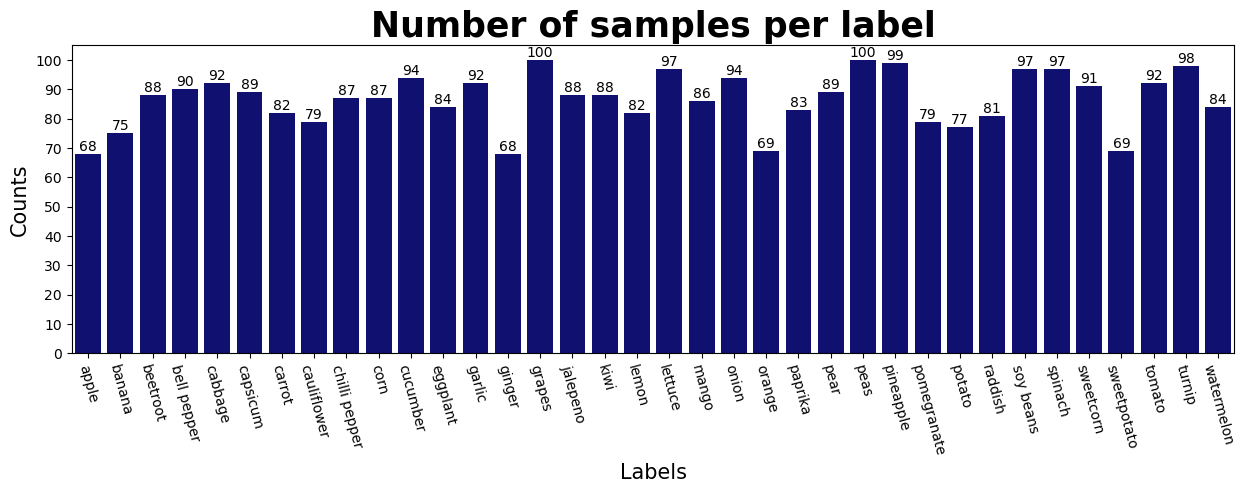

In [6]:
# work on train folder and count number of samples per each class
classes = [class_name for class_name in os.listdir(train_path)]
count = []
for class_name in classes :
    count.append(len(os.listdir(os.path.join(train_path, class_name))))

plt.figure(figsize=(15, 4))
ax = sns.barplot(x=classes, y=count, color='navy')
plt.xticks(rotation=285)
for i in ax.containers:
    ax.bar_label(i,)
plt.title('Number of samples per label', fontsize=25, fontweight='bold')
plt.xlabel('Labels', fontsize=15)
plt.ylabel('Counts', fontsize=15)
plt.yticks(np.arange(0, 105, 10))
plt.show()

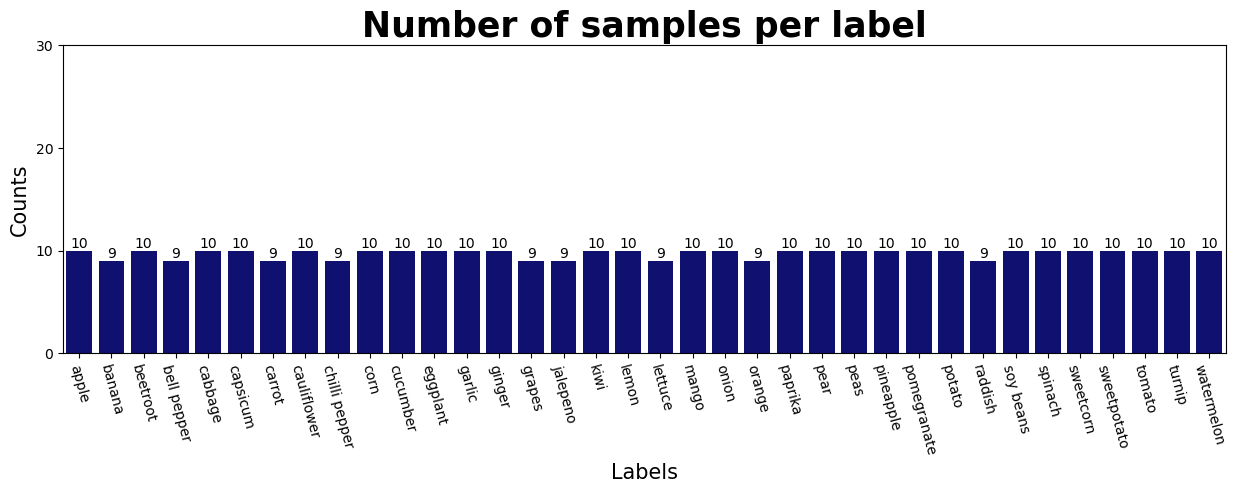

In [7]:
# work on validation folder and count number of samples per each class
classes = [class_name for class_name in os.listdir(val_path)]
count = []
for class_name in classes :
    count.append(len(os.listdir(os.path.join(val_path, class_name))))

plt.figure(figsize=(15, 4))
ax = sns.barplot(x=classes, y=count, color='navy')
plt.xticks(rotation=285)
for i in ax.containers:
    ax.bar_label(i,)
plt.title('Number of samples per label', fontsize=25, fontweight='bold')
plt.xlabel('Labels', fontsize=15)
plt.ylabel('Counts', fontsize=15)
plt.yticks(np.arange(0, 35, 10))
plt.show()

### Data Augmentation

In [8]:
#Create Image Generator
train_datagen = ImageDataGenerator(
    rescale = 1.0/255.0,
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip =True,
    fill_mode = "nearest"

)
#Create train Generator
train_generator =train_datagen.flow_from_directory(
    train_path,
    target_size = (150,150),
    batch_size = 32,
    class_mode = "categorical"
)

#Create test Generator
test_generator =train_datagen.flow_from_directory(
    test_path,
    target_size = (150,150),
    batch_size = 32,
    class_mode = "categorical"
)

#Create validation Generator
val_generator =train_datagen.flow_from_directory(
    val_path,
    target_size = (150,150),
    batch_size = 32,
    class_mode = "categorical"

)

Found 3115 images belonging to 36 classes.
Found 359 images belonging to 36 classes.
Found 351 images belonging to 36 classes.


In [9]:
#Access a batch
images, labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

#Print the class indices (folder names mapped to labels)
print("Class Indices:", train_generator.class_indices)

Images shape: (32, 150, 150, 3)
Labels shape: (32, 36)
Class Indices: {'apple': 0, 'banana': 1, 'beetroot': 2, 'bell pepper': 3, 'cabbage': 4, 'capsicum': 5, 'carrot': 6, 'cauliflower': 7, 'chilli pepper': 8, 'corn': 9, 'cucumber': 10, 'eggplant': 11, 'garlic': 12, 'ginger': 13, 'grapes': 14, 'jalepeno': 15, 'kiwi': 16, 'lemon': 17, 'lettuce': 18, 'mango': 19, 'onion': 20, 'orange': 21, 'paprika': 22, 'pear': 23, 'peas': 24, 'pineapple': 25, 'pomegranate': 26, 'potato': 27, 'raddish': 28, 'soy beans': 29, 'spinach': 30, 'sweetcorn': 31, 'sweetpotato': 32, 'tomato': 33, 'turnip': 34, 'watermelon': 35}


### Python Code for Displaying Images in a Grid

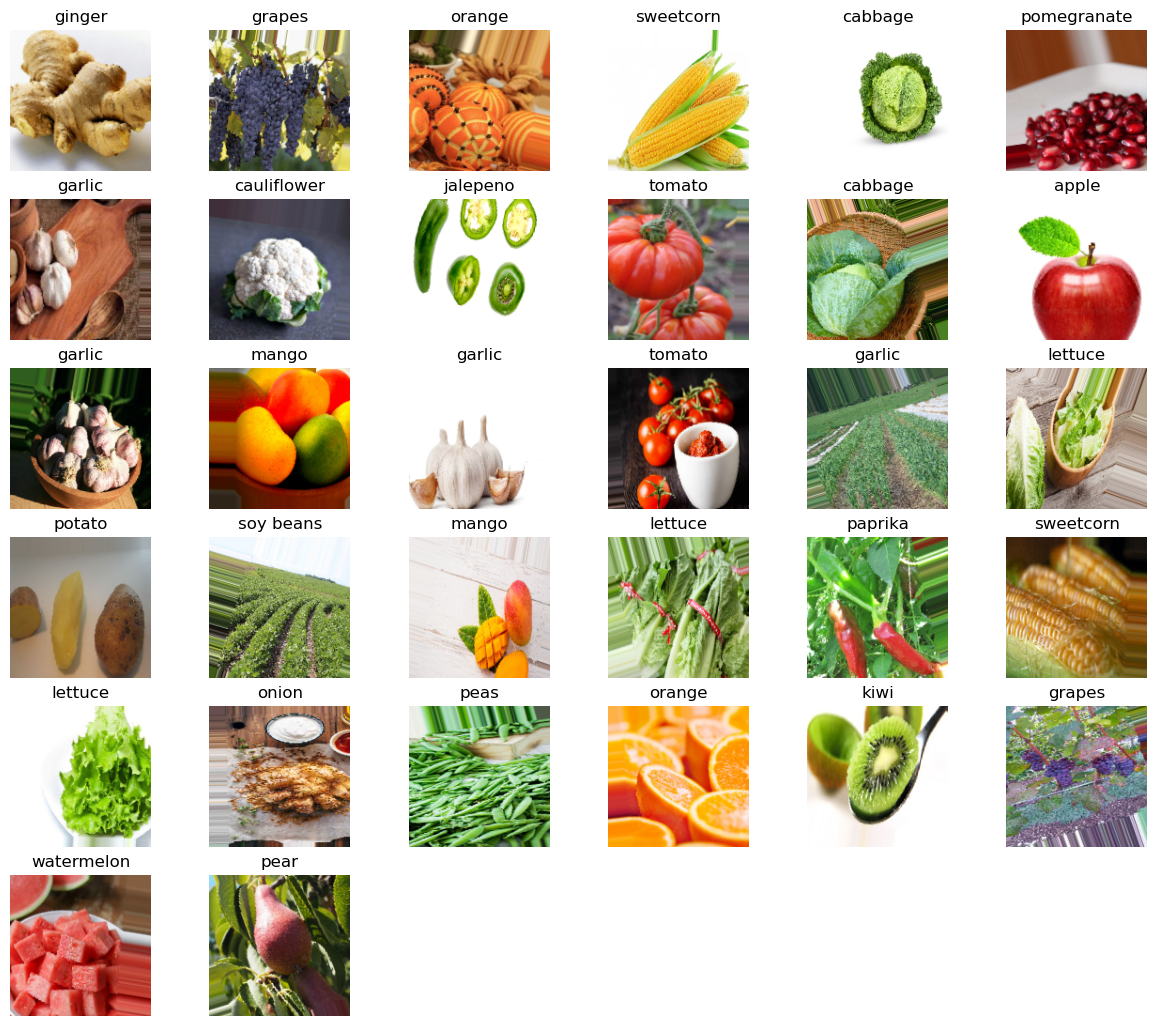

In [10]:
# Loop through the images and display them in a grid
plt.figure(figsize = (15,15))
for i in range(len(images)):
    ax = plt.subplot(7, 6, i + 1)  
    plt.imshow(images[i])
    plt.title(class_names[labels[i].argmax()])
    plt.axis("off")
plt.tight_layout
plt.show()

### Deep Learning Model with InceptionV3 Base

In [11]:
# Load InceptionV3 as the base model
base_model  = InceptionV3(input_shape = (150,150,3), include_top =False,weights = "imagenet")
base_model.trainable = True

#Define the model
model= Sequential([base_model,#inceptionV3 as the base model
                   GlobalAveragePooling2D(),#Replace Flatten Layer
                   Dense(512,activation = "relu"),#Dense layer
                   Dropout(0.5), #for Regularization
                   Dense(len(classes),activation="softmax")#output layer
])


#compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),loss="categorical_crossentropy",metrics=["accuracy"])

#Summary of the model
#print(model.summary())


: 

: 

### Training the Model

**The following code trains the defined deep learning model using a training and validation data generator.**

In [ ]:
#Train the model
history = model.fit(train_generator,epochs=40,validation_data=val_generator,steps_per_epoch=train_generator.samples // train_generator.batch_size,validation_steps = val_generator.samples // val_generator.batch_size)

NameError: name 'model' is not defined

### Plotting Training and Validation Accuracy

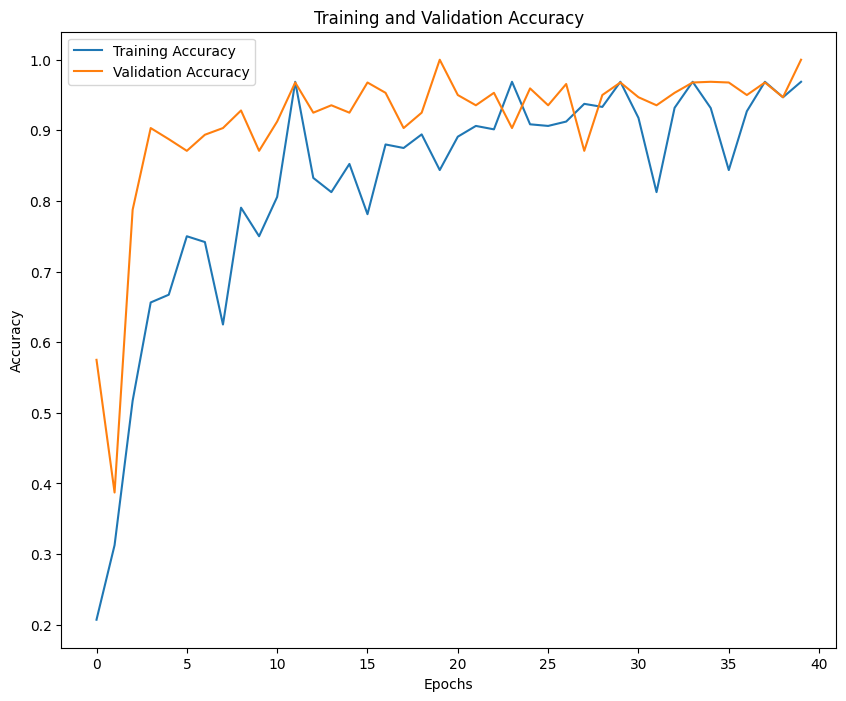

In [ ]:
#plot train and validation accuracy
plt.figure(figsize=(10,8))
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Plotting Training and Validation Loss

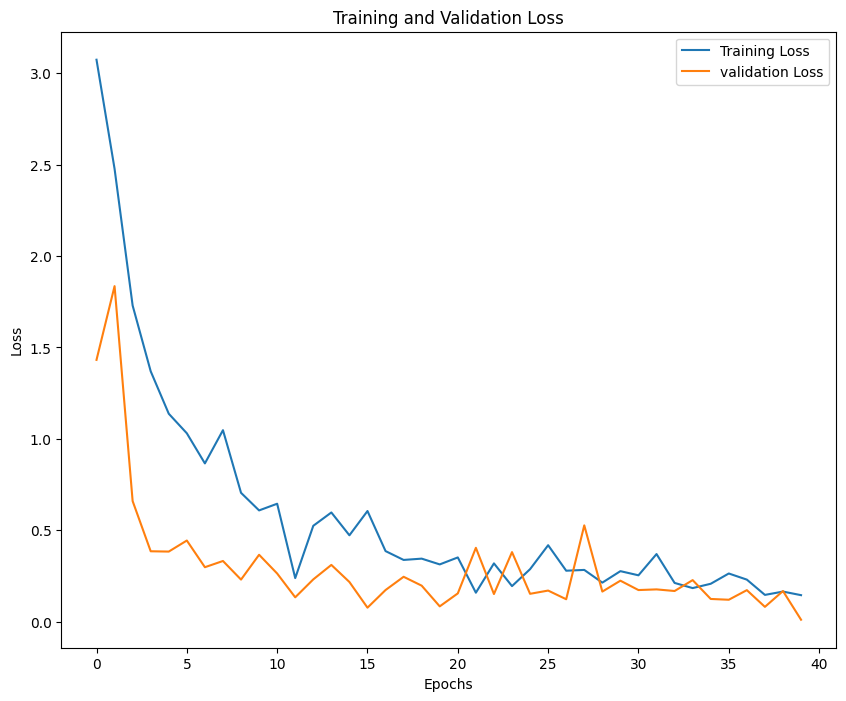

In [ ]:
#plot training and validation loss
plt.figure(figsize=(10,8))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Visualizing Model Predictions
**The function to visualize the model's predictions on a batch of images. It displays the predicted and actual labels and highlights correct predictions in green and incorrect predictions in red.**

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


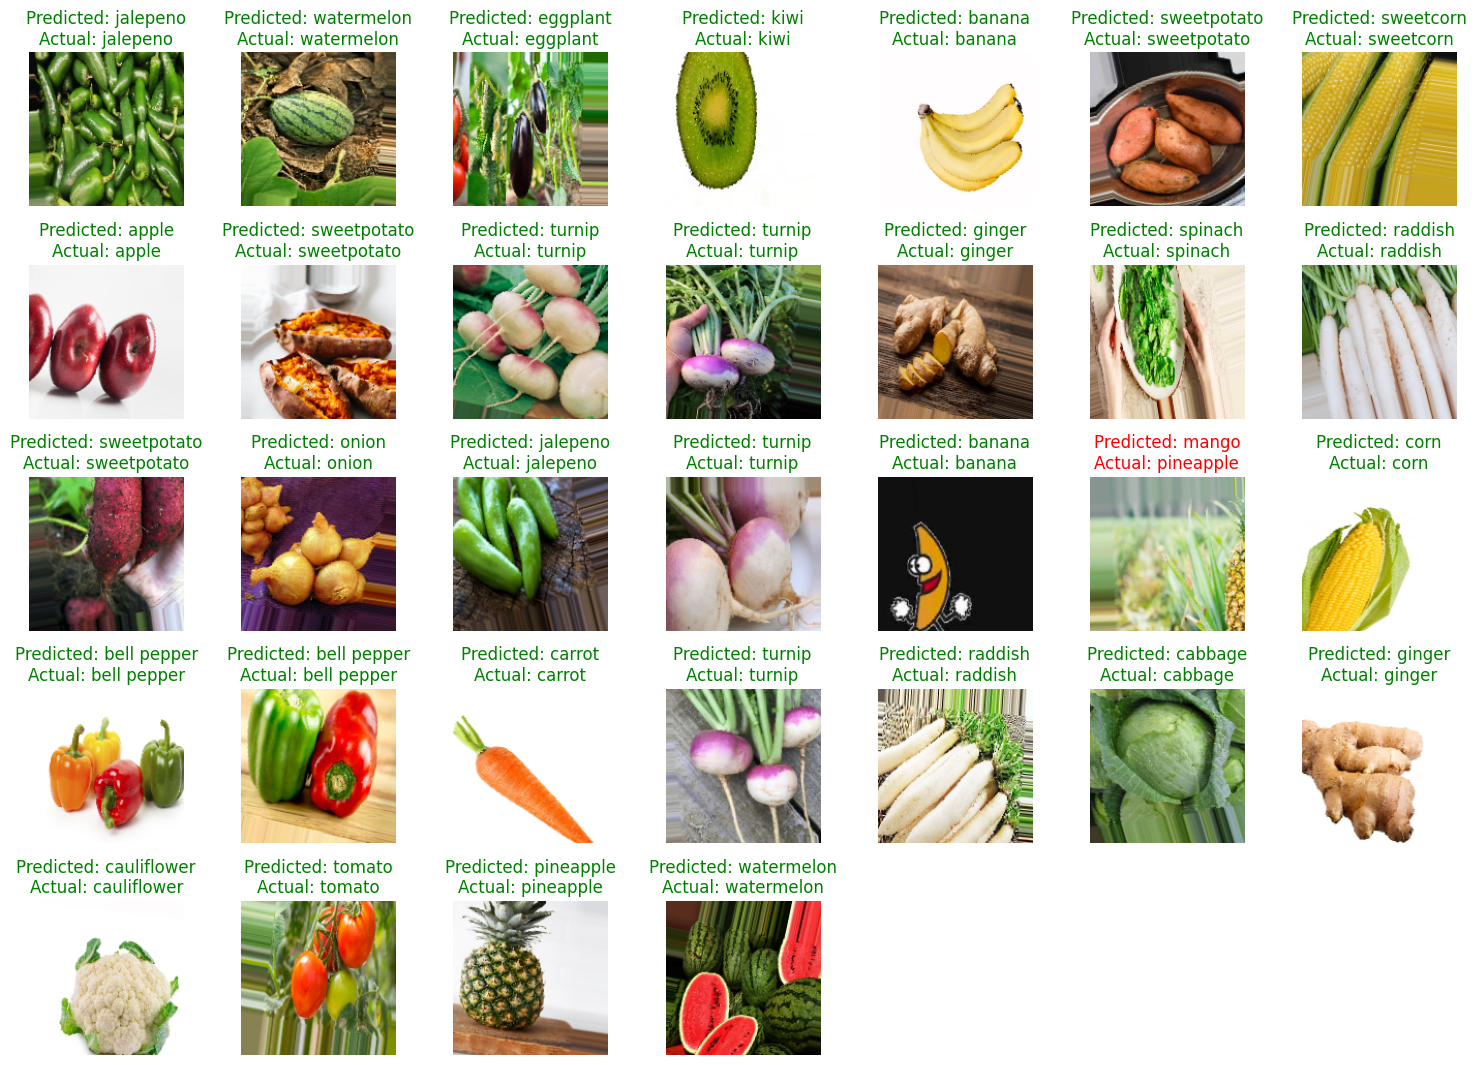

In [ ]:
def plot_predictions(generator,model,num_images):
  image , labels = next(generator)
  predictions = model.predict(image)
  predicted_labels = np.argmax(predictions ,axis =1)
  labels = np.argmax(labels,axis=1)
  class_name = list(generator.class_indices.keys())

  plt.figure(figsize=(15,15))
  grid_size = int(np.ceil(np.sqrt(num_images)))
  for i in range (len(image)):
    ax = plt.subplot(grid_size,grid_size,i+1)
    plt.imshow(image[i])
    if predicted_labels[i] == labels[i]:
      color= "green"
    else:
      color = "red"
    plt.title(f"Predicted: {class_name[predicted_labels[i]]}\nActual: {class_name[labels[i]]}",color=color)
    plt.axis("off")
    plt.tight_layout()
  plt.show()

plot_predictions(test_generator,model,37)